In [1]:
import pandas as pd
import numpy as np



In [2]:
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [3]:
top_sharpe = (
    perf.sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

top_sharpe[[
    "scheme_name",
    "sharpe_ratio"
]]

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [4]:
sharpe_rank = perf[[
    "scheme_name",
    "sharpe_ratio"
]].sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_rank.to_csv(
    "../data/processed/sharpe_ranking.csv",
    index=False
)

sharpe_rank.head()

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


In [5]:
alpha_beta = perf[[
    "scheme_name",
    "alpha",
    "beta"
]]

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [6]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [7]:
top_alpha = perf.sort_values(
    "alpha",
    ascending=False
).head(10)

top_alpha[[
    "scheme_name",
    "alpha"
]]

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
22,Kotak Flexicap Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,1.82
18,Nippon India ETF Nifty 50 BeES,1.80
33,UTI Flexi Cap Fund - Regular - Growth,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70


In [8]:
drawdown = perf.sort_values(
    "max_drawdown_pct"
)

drawdown[[
    "scheme_name",
    "max_drawdown_pct"
]].head(10)

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


In [9]:
score = perf.copy()

In [10]:
score["return_rank"] = score[
    "return_3yr_pct"
].rank(
    ascending=False
)

In [11]:
score["sharpe_rank"] = score[
    "sharpe_ratio"
].rank(
    ascending=False
)

In [12]:
score["alpha_rank"] = score[
    "alpha"
].rank(
    ascending=False
)

In [13]:
score["expense_rank"] = score[
    "expense_ratio_pct"
].rank(
    ascending=True
)

In [14]:
score["dd_rank"] = score[
    "max_drawdown_pct"
].rank(
    ascending=True
)

In [15]:
score["fund_score"] = (
    score["return_rank"] * 0.30 +
    score["sharpe_rank"] * 0.25 +
    score["alpha_rank"] * 0.20 +
    score["expense_rank"] * 0.15 +
    score["dd_rank"] * 0.10
)

In [16]:
score["fund_score"] = (
    100 -
    (
        score["fund_score"] /
        score["fund_score"].max()
    ) * 100
)

In [17]:
top_funds = score.sort_values(
    "fund_score",
    ascending=False
)

top_funds[[
    "scheme_name",
    "fund_score"
]].head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,61.980831
22,Kotak Flexicap Fund - Regular - Growth,60.383387
21,Kotak Emerging Equity Fund - Regular - Growth,59.105431
29,ABSL Small Cap Fund - Regular - Growth,56.230032
2,SBI Small Cap Fund - Regular Plan - Growth,51.277955
34,Mirae Asset Large Cap Fund - Regular - Growth,50.718850
9,HDFC Short Term Debt Fund - Regular - Growth,49.520767
14,ICICI Pru Liquid Fund - Regular - Growth,47.923323
12,ICICI Pru Midcap Fund - Regular - Growth,46.964856
11,ICICI Pru Bluechip Fund - Direct - Growth,45.207668


In [18]:
top_funds.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

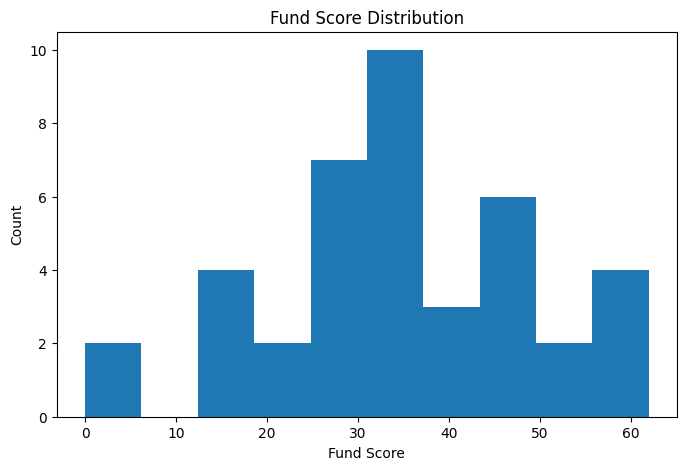

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    top_funds["fund_score"],
    bins=10
)

plt.title("Fund Score Distribution")
plt.xlabel("Fund Score")
plt.ylabel("Count")

plt.show()